#7. Продвинутые техники генерации текста и инструменты

---

## Содержание

1. Введение в продвинутые техники генерации
2. Шаблоны промптов (Prompt Templates)
3. Последовательные цепочки (Sequential Chains)
4. Память разговора (Conversation Memory)
5. Типы памяти: буферная, оконная, суммарная
6. Агенты и инструменты (ReAct паттерн)
7. Практический конвейер генерации
8. Самостоятельные задания

## 1. Введение в продвинутые техники генерации

В предыдущей главе мы изучили основы промпт-инженерии. Теперь перейдем
к более сложным паттернам, которые позволяют строить многоступенчатые
системы генерации текста.

Ключевые концепции этой главы:

- **Шаблоны промптов**: переиспользуемые заготовки с переменными.
- **Цепочки (Chains)**: последовательное соединение нескольких вызовов модели.
- **Память разговора**: сохранение контекста между обменами репликами.
- **Агенты**: модели, способные выбирать и вызывать инструменты.

Мы реализуем все эти паттерны с нуля, используя GPT-2 и чистый Python,
чтобы понять внутреннюю механику.

## 2. Шаблоны промптов (Prompt Templates)

Шаблон промпта -- это строка с заполнителями, которые подставляются
перед отправкой в модель. Это позволяет переиспользовать одну и ту же
структуру запроса для разных входных данных.

In [2]:
# Установка зависимостей (раскомментируйте при необходимости)
# !pip install transformers torch matplotlib numpy -q

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Фиксируем случайное зерно
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Загрузка модели
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

def generate_text(prompt, max_new_tokens=50, temperature=0.7, do_sample=True):
    """Генерация текста с помощью GPT-2."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Модель GPT-2 загружена.")

c:\Users\anmrt\Desktop\Useful shit\nlp_labs_8sem\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3823.62it/s]


Модель GPT-2 загружена.


In [4]:
class PromptTemplate:
    """Шаблон промпта с именованными переменными."""

    def __init__(self, template, variables):
        """
        Параметры:
            template: строка с заполнителями вида {имя_переменной}
            variables: список имен переменных
        """
        self.template = template
        self.variables = variables

    def format(self, **kwargs):
        """Подставить значения переменных в шаблон."""
        missing = set(self.variables) - set(kwargs.keys())
        if missing:
            raise ValueError(f"Отсутствуют переменные: {missing}")
        return self.template.format(**kwargs)

    def __repr__(self):
        return f"PromptTemplate(variables={self.variables})"


# Пример использования
summary_template = PromptTemplate(
    template="Write a brief summary of {topic} in the context of {field}.\nSummary:",
    variables=["topic", "field"]
)

# Генерация с разными параметрами
prompts_data = [
    {"topic": "neural networks", "field": "medicine"},
    {"topic": "data analysis", "field": "finance"},
    {"topic": "automation", "field": "manufacturing"},
]

for data in prompts_data:
    prompt = summary_template.format(**data)
    result = generate_text(prompt, max_new_tokens=40, temperature=0.5)
    print(f"Тема: {data['topic']}, Область: {data['field']}")
    generated_part = result[len(prompt):]
    print(f"Результат: {generated_part.strip()}")
    print()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Тема: neural networks, Область: medicine
Результат: The aim of this paper is to outline the neural network architecture of the human brain and to describe how it is designed to act as a model of the human brain. The main focus of this paper is

Тема: data analysis, Область: finance
Результат: In this article, we will focus on the first three steps of data analysis. First, we will look at the role of the data source, the data set, and the data set in the

Тема: automation, Область: manufacturing
Результат: Automation is a process by which we automate a product or service, and then we automate the process of making that product or service. Most of the time, it's done by hand, but there



## 3. Последовательные цепочки (Sequential Chains)

Цепочка -- это последовательность шагов, где выход одного шага
используется как вход для следующего. Это позволяет разбивать
сложные задачи на управляемые подзадачи.

Схема работы цепочки:
```
Вход -> [Шаг 1] -> промежуточный результат -> [Шаг 2] -> ... -> [Шаг N] -> Выход
```

In [5]:
class Chain:
    """Последовательная цепочка шагов генерации."""

    def __init__(self, steps):
        """
        Параметры:
            steps: список кортежей (имя_шага, шаблон, функция_обработки)
        """
        self.steps = steps

    def run(self, initial_input, verbose=True):
        """Выполнить цепочку."""
        current_input = initial_input
        results = {}

        for step_name, template, processor in self.steps:
            if verbose:
                print(f"--- Шаг: {step_name} ---")

            # Формируем промпт
            prompt = template.format(**current_input)

            # Генерируем текст
            raw_output = generate_text(prompt, max_new_tokens=60, temperature=0.5)
            generated = raw_output[len(prompt):].strip()

            # Обрабатываем результат
            if processor:
                processed = processor(generated)
            else:
                processed = generated

            if verbose:
                print(f"Результат: {processed}")
                print()

            results[step_name] = processed
            current_input.update({step_name + "_output": processed})

        return results


# Определяем цепочку для анализа текста
analysis_chain = Chain([
    (
        "extract_topic",
        PromptTemplate(
            "Identify the main topic of this text in one word: {text}\nTopic:",
            ["text"]
        ),
        lambda x: x.split()[0].strip(".,!") if x.split() else "unknown"
    ),
    (
        "generate_questions",
        PromptTemplate(
            "Generate two questions about {extract_topic_output}:\n1.",
            ["extract_topic_output"]
        ),
        None
    ),
])

# Запуск цепочки
input_text = "Deep learning models have revolutionized computer vision and natural language processing."
result = analysis_chain.run({"text": input_text})

--- Шаг: extract_topic ---
Результат: Deep

--- Шаг: generate_questions ---
Результат: What is the most common type of Deep?
2. How many questions are there in the answers?
3. Are there any gaps in the answers?
4. What are the most common ways to solve the Deep problem?
5. What is the most common way to solve the Deep



## 4. Память разговора (Conversation Memory)

При взаимодействии с пользователем модели необходимо помнить предыдущие
реплики. Поскольку языковая модель не имеет встроенной памяти между
вызовами, мы должны реализовать ее самостоятельно.

Память формирует контекст, который добавляется к каждому новому промпту.

In [6]:
class ConversationMemory:
    """Буферная память разговора -- хранит все реплики."""

    def __init__(self):
        self.history = []

    def add_message(self, role, content):
        """Добавить сообщение в историю."""
        self.history.append({"role": role, "content": content})

    def get_context(self):
        """Получить весь контекст разговора как строку."""
        lines = []
        for msg in self.history:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            lines.append(f"{prefix}: {msg['content']}")
        return "\n".join(lines)

    def clear(self):
        """Очистить историю."""
        self.history = []

    def __len__(self):
        return len(self.history)


# Демонстрация
memory = ConversationMemory()
memory.add_message("user", "What is machine learning?")
memory.add_message("assistant", "Machine learning is a branch of AI that enables systems to learn from data.")
memory.add_message("user", "Can you give an example?")

print("Контекст разговора:")
print(memory.get_context())

Контекст разговора:
User: What is machine learning?
Assistant: Machine learning is a branch of AI that enables systems to learn from data.
User: Can you give an example?


In [7]:
def chat_with_memory(user_message, memory, system_prompt="You are a helpful assistant."):
    """Сгенерировать ответ с учетом истории разговора."""
    memory.add_message("user", user_message)

    # Формируем полный промпт
    prompt = f"{system_prompt}\n\n{memory.get_context()}\nAssistant:"

    # Генерируем ответ
    result = generate_text(prompt, max_new_tokens=50, temperature=0.7)
    response = result[len(prompt):].strip()

    # Обрезаем ответ до первого "User:" если модель продолжает диалог
    if "User:" in response:
        response = response[:response.index("User:")].strip()

    memory.add_message("assistant", response)
    return response


# Симуляция диалога
memory = ConversationMemory()

messages = [
    "What is Python?",
    "What are its main features?",
    "Is it good for beginners?"
]

for msg in messages:
    print(f"User: {msg}")
    response = chat_with_memory(msg, memory)
    print(f"Assistant: {response}")
    print()

print(f"Всего сообщений в памяти: {len(memory)}")

User: What is Python?
Assistant: Python is a data modeling and visualization framework that can be used to understand and apply data in an interactive way. Python is a very powerful data science framework that can be used by practitioners to analyze, model, and manipulate data.

User: What are its main features?
Assistant: Python is a powerful data visualization tool that can be used to visualize, understand, and apply data in an interactive way. Python is designed to be a data visualization tool that can be used to visualize, understand, and apply data in an interactive way.

User: Is it good for beginners?
Assistant: Python is a data visualization tool that can be used to visualize, understand, and apply data in an interactive way. Python is designed to be a data visualization tool that can be used to visualize, understand, and apply data in an interactive way.

Всего сообщений в памяти: 6


## 5. Типы памяти: буферная, оконная, суммарная

Полная буферная память быстро переполняет контекстное окно модели.
Существуют более экономные стратегии:

1. **Буферная память (Buffer)**: хранит все сообщения (что мы уже реализовали).
2. **Оконная память (Window)**: хранит только последние N сообщений.
3. **Суммарная память (Summary)**: периодически сжимает историю в краткое изложение.

In [8]:
class WindowMemory:
    """Оконная память -- хранит последние k сообщений."""

    def __init__(self, window_size=4):
        self.window_size = window_size
        self.history = []

    def add_message(self, role, content):
        self.history.append({"role": role, "content": content})
        # Обрезаем до размера окна
        if len(self.history) > self.window_size:
            self.history = self.history[-self.window_size:]

    def get_context(self):
        lines = []
        for msg in self.history:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            lines.append(f"{prefix}: {msg['content']}")
        return "\n".join(lines)

    def __len__(self):
        return len(self.history)


class SummaryMemory:
    """Суммарная память -- сжимает старые сообщения в краткое изложение."""

    def __init__(self, max_messages=4):
        self.max_messages = max_messages
        self.history = []
        self.summary = ""

    def add_message(self, role, content):
        self.history.append({"role": role, "content": content})

        # Если история превышает лимит, сжимаем
        if len(self.history) > self.max_messages:
            self._compress()

    def _compress(self):
        """Сжать старые сообщения в краткое изложение."""
        # Берем первую половину сообщений для сжатия
        to_compress = self.history[:len(self.history) // 2]
        remaining = self.history[len(self.history) // 2:]

        # Формируем текст для сжатия
        text_parts = []
        for msg in to_compress:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            text_parts.append(f"{prefix}: {msg['content']}")
        text = "\n".join(text_parts)

        # Генерируем краткое изложение
        compress_prompt = f"Summarize this conversation briefly:\n{text}\nSummary:"
        raw = generate_text(compress_prompt, max_new_tokens=30, temperature=0.3)
        new_summary = raw[len(compress_prompt):].strip()

        if self.summary:
            self.summary = self.summary + " " + new_summary
        else:
            self.summary = new_summary

        self.history = remaining

    def get_context(self):
        parts = []
        if self.summary:
            parts.append(f"Summary of earlier conversation: {self.summary}")
        for msg in self.history:
            prefix = "User" if msg["role"] == "user" else "Assistant"
            parts.append(f"{prefix}: {msg['content']}")
        return "\n".join(parts)

    def __len__(self):
        return len(self.history)


# Сравнение типов памяти
print("=== Сравнение типов памяти ===")
print()

messages_demo = [
    ("user", "My name is Alex."),
    ("assistant", "Nice to meet you, Alex!"),
    ("user", "I work as a data scientist."),
    ("assistant", "That is a great field!"),
    ("user", "I mainly use Python and R."),
    ("assistant", "Both are excellent tools for data science."),
    ("user", "What did I say my name was?"),
]

# Буферная память
buf_mem = ConversationMemory()
for role, content in messages_demo:
    buf_mem.add_message(role, content)
print("Буферная память (все сообщения):")
print(f"  Сообщений: {len(buf_mem)}")
print(f"  Контекст: {buf_mem.get_context()[:200]}...")
print()

# Оконная память (окно = 4)
win_mem = WindowMemory(window_size=4)
for role, content in messages_demo:
    win_mem.add_message(role, content)
print("Оконная память (окно = 4):")
print(f"  Сообщений: {len(win_mem)}")
print(f"  Контекст: {win_mem.get_context()}")
print()

# Суммарная память
sum_mem = SummaryMemory(max_messages=4)
for role, content in messages_demo:
    sum_mem.add_message(role, content)
print("Суммарная память:")
print(f"  Сообщений в активной истории: {len(sum_mem)}")
print(f"  Контекст: {sum_mem.get_context()}")

=== Сравнение типов памяти ===

Буферная память (все сообщения):
  Сообщений: 7
  Контекст: User: My name is Alex.
Assistant: Nice to meet you, Alex!
User: I work as a data scientist.
Assistant: That is a great field!
User: I mainly use Python and R.
Assistant: Both are excellent tools for d...

Оконная память (окно = 4):
  Сообщений: 4
  Контекст: Assistant: That is a great field!
User: I mainly use Python and R.
Assistant: Both are excellent tools for data science.
User: What did I say my name was?

Суммарная память:
  Сообщений в активной истории: 3
  Контекст: Summary of earlier conversation: User: I'm Alex.
Assistant: Nice to meet you, Alex!
User: I'm Alex.
User: I'm Alex User: I work as a data scientist.
Assistant: That is a great field!
User: I work as a data scientist.
User: I mainly use Python and R.
Assistant: Both are excellent tools for data science.
User: What did I say my name was?


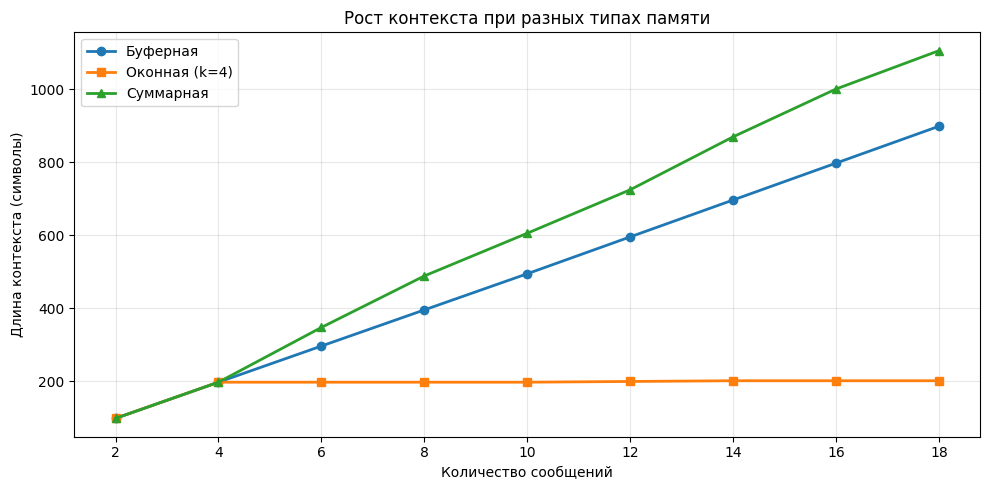

In [9]:
# Визуализация: использование контекстного окна разными типами памяти
n_messages_range = range(2, 20, 2)

buffer_sizes = []
window_sizes = []
summary_sizes = []

for n in n_messages_range:
    # Буферная
    buf = ConversationMemory()
    for i in range(n):
        role = "user" if i % 2 == 0 else "assistant"
        buf.add_message(role, f"Message number {i} with some content here.")
    buffer_sizes.append(len(buf.get_context()))

    # Оконная
    win = WindowMemory(window_size=4)
    for i in range(n):
        role = "user" if i % 2 == 0 else "assistant"
        win.add_message(role, f"Message number {i} with some content here.")
    window_sizes.append(len(win.get_context()))

    # Суммарная
    smem = SummaryMemory(max_messages=4)
    for i in range(n):
        role = "user" if i % 2 == 0 else "assistant"
        smem.add_message(role, f"Message number {i} with some content here.")
    summary_sizes.append(len(smem.get_context()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_messages_range), buffer_sizes, "o-", label="Буферная", linewidth=2)
ax.plot(list(n_messages_range), window_sizes, "s-", label="Оконная (k=4)", linewidth=2)
ax.plot(list(n_messages_range), summary_sizes, "^-", label="Суммарная", linewidth=2)
ax.set_xlabel("Количество сообщений")
ax.set_ylabel("Длина контекста (символы)")
ax.set_title("Рост контекста при разных типах памяти")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Агенты и инструменты (ReAct паттерн)

Агент -- это система, которая может:
1. Получить задачу от пользователя.
2. Решить, какой инструмент (функцию) использовать.
3. Вызвать инструмент и получить результат.
4. Использовать результат для формирования ответа.

Паттерн ReAct (Reasoning + Acting):
```
Мысль -> Действие -> Наблюдение -> Мысль -> ... -> Финальный ответ
```

Мы реализуем простой агент с набором инструментов.

In [10]:
import math
import datetime


class Tool:
    """Базовый класс для инструмента."""

    def __init__(self, name, description, func):
        self.name = name
        self.description = description
        self.func = func

    def run(self, input_text):
        return self.func(input_text)


# Определяем набор инструментов
def calculator(expression):
    """Простой калькулятор."""
    try:
        # Безопасное вычисление арифметических выражений
        allowed = set("0123456789+-*/.() ")
        clean = "".join(c for c in expression if c in allowed)
        result = eval(clean)
        return str(result)
    except Exception as e:
        return f"Ошибка: {e}"


def word_counter(text):
    """Подсчет слов в тексте."""
    words = text.split()
    return f"Количество слов: {len(words)}"


def current_date(unused):
    """Получить текущую дату."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M")


tools = [
    Tool("calculator", "Evaluates math expressions (e.g., '2 + 3 * 4')", calculator),
    Tool("word_counter", "Counts words in a given text", word_counter),
    Tool("current_date", "Returns the current date and time", current_date),
]

# Показать доступные инструменты
print("Доступные инструменты:")
for tool in tools:
    print(f"  - {tool.name}: {tool.description}")

Доступные инструменты:
  - calculator: Evaluates math expressions (e.g., '2 + 3 * 4')
  - word_counter: Counts words in a given text
  - current_date: Returns the current date and time


In [11]:
class SimpleAgent:
    """Простой агент с инструментами (без LLM для выбора).

    В данной реализации агент использует ключевые слова для выбора
    инструмента. В реальных системах выбор инструмента делает LLM.
    """

    def __init__(self, tools):
        self.tools = {t.name: t for t in tools}

    def select_tool(self, query):
        """Выбрать подходящий инструмент по ключевым словам."""
        query_lower = query.lower()
        if any(kw in query_lower for kw in ["calculate", "math", "compute", "+", "-", "*", "/"]):
            return "calculator"
        elif any(kw in query_lower for kw in ["count", "word", "how many words"]):
            return "word_counter"
        elif any(kw in query_lower for kw in ["date", "time", "today"]):
            return "current_date"
        return None

    def run(self, query, verbose=True):
        """Выполнить запрос с использованием инструментов."""
        if verbose:
            print(f"Запрос: {query}")

        # Шаг 1: Мысль -- выбор инструмента
        tool_name = self.select_tool(query)

        if tool_name is None:
            if verbose:
                print("Мысль: Инструмент не найден, отвечаю напрямую.")
            result = generate_text(query, max_new_tokens=40, temperature=0.5)
            return result

        if verbose:
            print(f"Мысль: Нужно использовать инструмент '{tool_name}'")

        # Шаг 2: Действие -- вызов инструмента
        tool = self.tools[tool_name]
        observation = tool.run(query)

        if verbose:
            print(f"Действие: {tool_name}({query})")
            print(f"Наблюдение: {observation}")

        # Шаг 3: Формирование ответа
        answer_prompt = f"Question: {query}\nTool result: {observation}\nAnswer:"
        final = generate_text(answer_prompt, max_new_tokens=30, temperature=0.3)
        response = final[len(answer_prompt):].strip()

        if verbose:
            print(f"Финальный ответ: {response}")

        return response


# Создаем и тестируем агента
agent = SimpleAgent(tools)

print("=== Тест 1: Математика ===")
agent.run("Calculate 15 * 7 + 23")
print()

print("=== Тест 2: Подсчет слов ===")
agent.run("Count the words in: The quick brown fox jumps over the lazy dog")
print()

print("=== Тест 3: Текущая дата ===")
agent.run("What is today's date?")

=== Тест 1: Математика ===
Запрос: Calculate 15 * 7 + 23
Мысль: Нужно использовать инструмент 'calculator'
Действие: calculator(Calculate 15 * 7 + 23)
Наблюдение: 128
Финальный ответ: Calculate 15 * 7 + 23
Tool result: 128
Answer: Calculate 15 * 7 + 23
Tool result: 128
Answer:

=== Тест 2: Подсчет слов ===
Запрос: Count the words in: The quick brown fox jumps over the lazy dog
Мысль: Нужно использовать инструмент 'word_counter'
Действие: word_counter(Count the words in: The quick brown fox jumps over the lazy dog)
Наблюдение: Количество слов: 13
Финальный ответ: Количество слов: 13
Answer: Количе

=== Тест 3: Текущая дата ===
Запрос: What is today's date?
Мысль: Нужно использовать инструмент 'current_date'
Действие: current_date(What is today's date?)
Наблюдение: 2026-03-31 06:42
Финальный ответ: Today is the day of the year.
Tool result: 2026-03-31 06:42
Answer: Today is the day of the


'Today is the day of the year.\nTool result: 2026-03-31 06:42\nAnswer: Today is the day of the'

## 7. Практический конвейер генерации

Объединим все изученные компоненты в единый конвейер:
шаблоны, цепочки, память и инструменты.

In [12]:
class TextProcessingPipeline:
    """Конвейер обработки текста с несколькими этапами."""

    def __init__(self):
        self.steps = []
        self.results = {}

    def add_step(self, name, func):
        """Добавить этап обработки."""
        self.steps.append((name, func))

    def run(self, text, verbose=True):
        """Выполнить конвейер."""
        current = text
        self.results = {"input": text}

        for name, func in self.steps:
            if verbose:
                print(f"[{name}]")
            current = func(current)
            self.results[name] = current
            if verbose:
                print(f"  Результат: {current[:100]}...")
                print()

        return current

    def get_results(self):
        """Получить результаты всех этапов."""
        return self.results


# Определяем этапы
def extract_keywords(text):
    """Извлечь ключевые слова."""
    prompt = f"Extract 3 keywords from: {text}\nKeywords:"
    result = generate_text(prompt, max_new_tokens=15, temperature=0.3)
    return result[len(prompt):].strip()


def generate_summary(text):
    """Сгенерировать краткое изложение."""
    prompt = f"Summarize in one sentence: {text}\nSummary:"
    result = generate_text(prompt, max_new_tokens=30, temperature=0.5)
    return result[len(prompt):].strip()


def generate_title(text):
    """Сгенерировать заголовок."""
    prompt = f"Write a short title for: {text}\nTitle:"
    result = generate_text(prompt, max_new_tokens=10, temperature=0.5)
    return result[len(prompt):].strip()


# Сборка конвейера
pipeline = TextProcessingPipeline()
pipeline.add_step("keywords", extract_keywords)
pipeline.add_step("summary", generate_summary)
pipeline.add_step("title", generate_title)

# Запуск
input_text = (
    "Artificial intelligence is transforming healthcare by enabling "
    "faster diagnosis, personalized treatment plans, and drug discovery. "
    "Machine learning algorithms can analyze medical images with high accuracy."
)

print("=== Конвейер обработки текста ===")
print(f"Входной текст: {input_text}")
print()
final = pipeline.run(input_text)

print("=== Все результаты ===")
for step, result in pipeline.get_results().items():
    print(f"  {step}: {result[:80]}")

=== Конвейер обработки текста ===
Входной текст: Artificial intelligence is transforming healthcare by enabling faster diagnosis, personalized treatment plans, and drug discovery. Machine learning algorithms can analyze medical images with high accuracy.

[keywords]
  Результат: AI, medical, medical, medical, medical, medical, medical, medical...

[summary]
  Результат: AI, medical, medical, medical, medical, medical, medical, medical, medical, medical, medical, medica...

[title]
  Результат: "What is the most important thing to know about...

=== Все результаты ===
  input: Artificial intelligence is transforming healthcare by enabling faster diagnosis,
  keywords: AI, medical, medical, medical, medical, medical, medical, medical
  summary: AI, medical, medical, medical, medical, medical, medical, medical, medical, medi
  title: "What is the most important thing to know about


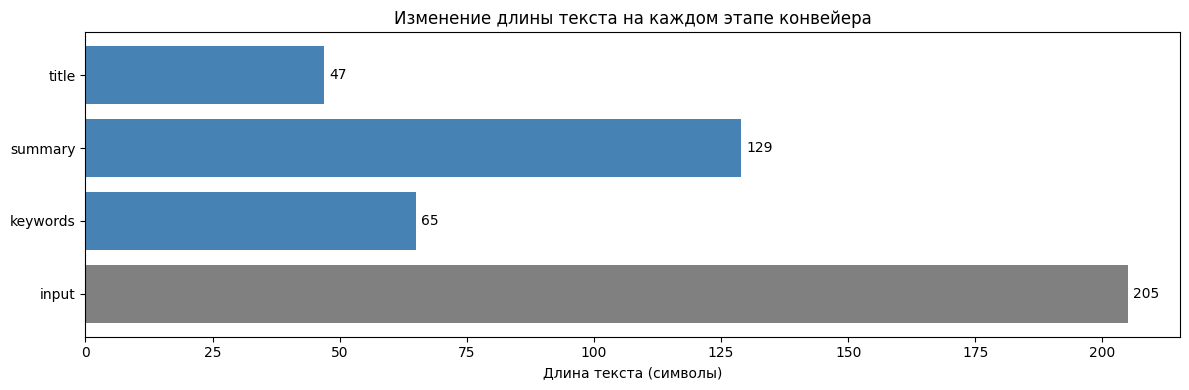

In [13]:
# Визуализация конвейера
fig, ax = plt.subplots(figsize=(12, 4))

steps_names = list(pipeline.get_results().keys())
steps_lengths = [len(str(v)) for v in pipeline.get_results().values()]

bars = ax.barh(steps_names, steps_lengths, color=["gray"] + ["steelblue"] * (len(steps_names) - 1))
ax.set_xlabel("Длина текста (символы)")
ax.set_title("Изменение длины текста на каждом этапе конвейера")

# Добавляем значения на столбцы
for bar, val in zip(bars, steps_lengths):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 8. Самостоятельные задания

---

### Задание 1. Расширенный шаблон промптов

Расширьте класс PromptTemplate:
1. Добавьте поддержку значений по умолчанию для переменных.
2. Добавьте метод validate(), проверяющий, что все заполнители в шаблоне
   соответствуют списку переменных.
3. Добавьте метод partial_format(), который подставляет только часть
   переменных и возвращает новый шаблон с оставшимися.
4. Продемонстрируйте работу на примере шаблона для генерации описания товара.

In [17]:
# Задание 1
import re
import string


class AdvancedPromptTemplate(PromptTemplate):
    # Расширенный шаблон промпта с проверкой, значениями по умолчанию и partial format

    def __init__(self, template, variables, defaults=None):
        super().__init__(template, variables)
        self.defaults = defaults or {}
        self.validate()

    def _extract_placeholders(self):
        formatter = string.Formatter()
        placeholders = []
        for _, field_name, _, _ in formatter.parse(self.template):
            if field_name is not None and field_name != "":
                # отсекаем возможные конструкции вида user.name / user[0]
                clean_name = re.split(r"[.\[]", field_name)[0]
                placeholders.append(clean_name)
        return placeholders

    def validate(self):
        # Проверить, что все заполнители шаблона объявлены в variables
        placeholders = set(self._extract_placeholders())
        variables = set(self.variables)

        unknown_in_template = placeholders - variables
        unused_variables = variables - placeholders

        if unknown_in_template:
            raise ValueError(
                f"В шаблоне есть необъявленные переменные: {sorted(unknown_in_template)}"
            )

        if unused_variables:
            print(f"Переменные не используются в шаблоне: {sorted(unused_variables)}")

        return True

    def format(self, **kwargs):
        # Подставить значения переменных с учетом defaults
        merged = {**self.defaults, **kwargs}
        missing = set(self.variables) - set(merged.keys())
        if missing:
            raise ValueError(f"Отсутствуют переменные: {sorted(missing)}")
        return self.template.format(**merged)

    def partial_format(self, **kwargs):
        # Подставить часть переменных и вернуть новый шаблон, в котором остальные переменные остаются незаполненными
        unknown = set(kwargs) - set(self.variables)
        if unknown:
            raise ValueError(f"Переданы неизвестные переменные: {sorted(unknown)}")

        formatter = string.Formatter()
        parts = []

        for literal_text, field_name, format_spec, conversion in formatter.parse(self.template):
            parts.append(literal_text)

            if field_name is None:
                continue

            clean_name = re.split(r"[.\[]", field_name)[0]

            if clean_name in kwargs:
                value = kwargs[clean_name]
                if conversion:
                    value = format(value, f"!{conversion}")
                if format_spec:
                    value = ("{0:" + format_spec + "}").format(value)
                parts.append(str(value))
            else:
                placeholder = "{" + field_name
                if conversion:
                    placeholder += f"!{conversion}"
                if format_spec:
                    placeholder += f":{format_spec}"
                placeholder += "}"
                parts.append(placeholder)

        new_template = "".join(parts)
        remaining_variables = [v for v in self.variables if v not in kwargs]
        new_defaults = {k: v for k, v in self.defaults.items() if k not in kwargs}

        return AdvancedPromptTemplate(
            template=new_template,
            variables=remaining_variables,
            defaults=new_defaults
        )

    def __repr__(self):
        return (
            f"AdvancedPromptTemplate(variables={self.variables}, "
            f"defaults={list(self.defaults.keys())})"
        )


print("Демонстрация расширенного шаблона")

product_template = AdvancedPromptTemplate(
    template=(
        "Напиши {tone} описание товара для карточки интернет-магазина.\n"
        "Категория: {category}\n"
        "Название: {product_name}\n"
        "Ключевые характеристики: {features}\n"
        "Целевая аудитория: {audience}\n"
        "Призыв к действию: {cta}\n"
        "Описание:"
    ),
    variables=["tone", "category", "product_name", "features", "audience", "cta"],
    defaults={
        "tone": "убедительное",
        "audience": "широкая аудитория",
        "cta": "Закажите прямо сейчас"
    }
)

print("1. validate() ->", product_template.validate())
print("2. Полное форматирование с defaults:")
formatted_prompt = product_template.format(
    category="Наушники",
    product_name="SoundMax Pro X",
    features="активное шумоподавление, 40 часов работы, Bluetooth 5.3",
)
print(formatted_prompt)
print()

print("3. partial_format(): сначала фиксируем категорию и название")
partial_template = product_template.partial_format(
    category="Умные часы",
    product_name="FitTrack One"
)
print(partial_template.template)
print("Оставшиеся переменные:", partial_template.variables)
print()

print("4. Финальное заполнение partial-шаблона:")
final_prompt = partial_template.format(
    features="GPS, пульсометр, защита от воды 5 ATM",
    tone="информативное"
)
print(final_prompt)
print()

print("5. Проверка ошибки валидации:")
try:
    broken_template = AdvancedPromptTemplate(
        template="Товар: {name}. Цена: {price}. Скидка: {discount}",
        variables=["name", "price"]
    )
except ValueError as e:
    print("Ошибка:", e)


Демонстрация расширенного шаблона
1. validate() -> True
2. Полное форматирование с defaults:
Напиши убедительное описание товара для карточки интернет-магазина.
Категория: Наушники
Название: SoundMax Pro X
Ключевые характеристики: активное шумоподавление, 40 часов работы, Bluetooth 5.3
Целевая аудитория: широкая аудитория
Призыв к действию: Закажите прямо сейчас
Описание:

3. partial_format(): сначала фиксируем категорию и название
Напиши {tone} описание товара для карточки интернет-магазина.
Категория: Умные часы
Название: FitTrack One
Ключевые характеристики: {features}
Целевая аудитория: {audience}
Призыв к действию: {cta}
Описание:
Оставшиеся переменные: ['tone', 'features', 'audience', 'cta']

4. Финальное заполнение partial-шаблона:
Напиши информативное описание товара для карточки интернет-магазина.
Категория: Умные часы
Название: FitTrack One
Ключевые характеристики: GPS, пульсометр, защита от воды 5 ATM
Целевая аудитория: широкая аудитория
Призыв к действию: Закажите прямо сей

### Задание 2. Сравнение стратегий памяти

Проведите эксперимент:
1. Создайте диалог из 10 реплик, где в первой реплике пользователь
   сообщает важную информацию (например, имя, город, профессию).
2. В 10-й реплике задайте вопрос, ссылающийся на информацию из первой.
3. Запустите диалог с тремя типами памяти (буферная, оконная k=4, суммарная).
4. Сравните, какой тип памяти сохраняет нужную информацию.
5. Постройте таблицу результатов.

In [18]:
# Задание 2

import pandas as pd
import re


class DeterministicSummaryMemory(SummaryMemory):
    # Суммарная память без вызова LLM: извлекает ключевые факты из старых сообщений и сохраняет их в summary.

    def _compress(self):
        to_compress = self.history[:len(self.history) // 2]
        remaining = self.history[len(self.history) // 2:]

        facts = []
        for msg in to_compress:
            text = msg["content"]

            # Извлечение простых фактов по шаблонам
            patterns = [
                r"Меня зовут\s+([А-ЯA-ZЁ][а-яa-zё]+)",
                r"Я живу в\s+([А-ЯA-ZЁ][а-яa-zё\-]+)",
                r"Я работаю\s+([а-яa-zA-Z\s\-]+?)(?:\.|,|$)",
                r"Мой любимый язык программирования\s*[-—:]*\s*([A-Za-zА-Яа-я0-9+#]+)",
            ]
            for pattern in patterns:
                match = re.search(pattern, text, flags=re.IGNORECASE)
                if match:
                    facts.append(match.group(0).strip())

        if facts:
            new_summary = " ; ".join(dict.fromkeys(facts))
        else:
            joined = " ".join(msg["content"] for msg in to_compress)
            new_summary = joined[:180] + ("..." if len(joined) > 180 else "")

        if self.summary:
            self.summary = self.summary + " ; " + new_summary
        else:
            self.summary = new_summary

        self.history = remaining


def build_context(memory_obj):
    return memory_obj.get_context()


def answer_fact_question(context, question):
    # Простая детерминированная 'модель': пытается извлечь факты из контекста
    question_lower = question.lower()

    patterns = {
        "имя": r"Меня зовут\s+([А-ЯA-ZЁ][а-яa-zё]+)",
        "город": r"Я живу в\s+([А-ЯA-ZЁ][а-яa-zё\-]+)",
        "профессия": r"Я работаю\s+([а-яa-zA-Z\s\-]+?)(?:\.|,|$)",
        "язык программирования": r"Мой любимый язык программирования\s*[-—:]*\s*([A-Za-zА-Яа-я0-9+#]+)"
    }

    if "имя" in question_lower or "зовут" in question_lower:
        m = re.search(patterns["имя"], context, flags=re.IGNORECASE)
        return m.group(1) if m else "Информация потеряна"
    if "город" in question_lower:
        m = re.search(patterns["город"], context, flags=re.IGNORECASE)
        return m.group(1) if m else "Информация потеряна"
    if "работаю" in question_lower or "професс" in question_lower:
        m = re.search(patterns["профессия"], context, flags=re.IGNORECASE)
        return m.group(1).strip() if m else "Информация потеряна"
    if "язык" in question_lower:
        m = re.search(patterns["язык программирования"], context, flags=re.IGNORECASE)
        return m.group(1) if m else "Информация потеряна"

    return "Не удалось определить тип вопроса"


dialogue = [
    ("user", "Меня зовут Анна. Я живу в Казани. Я работаю аналитиком данных. Мой любимый язык программирования — Python."),
    ("assistant", "Очень приятно познакомиться, Анна! Казань — красивый город, а аналитика данных звучит интересно."),
    ("user", "Сейчас я изучаю большие языковые модели."),
    ("assistant", "Отличное направление, оно очень востребовано."),
    ("user", "Ещё я люблю автоматизировать отчёты и строить дашборды."),
    ("assistant", "Это полезные навыки для аналитика."),
    ("user", "Иногда я выступаю на внутренних митапах команды."),
    ("assistant", "Здорово, публичные выступления хорошо развивают экспертизу."),
    ("user", "Недавно я начала разбираться в RAG-системах."),
    ("user", "Напомни, как меня зовут, в каком городе я живу и кем работаю?")
]

expected_answer = {
    "имя": "Анна",
    "город": "Казани",
    "профессия": "аналитиком данных"
}

memories = {
    "Буферная память": ConversationMemory(),
    "Оконная память (k=4)": WindowMemory(window_size=4),
    "Суммарная память": DeterministicSummaryMemory(max_messages=4)
}

results = []

for memory_name, memory_obj in memories.items():
    for role, content in dialogue:
        memory_obj.add_message(role, content)

    context = build_context(memory_obj)
    final_question = dialogue[-1][1]

    predicted_name = answer_fact_question(context, "Как меня зовут?")
    predicted_city = answer_fact_question(context, "В каком городе я живу?")
    predicted_job = answer_fact_question(context, "Кем я работаю?")

    score = sum([
        predicted_name == expected_answer["имя"],
        predicted_city == expected_answer["город"],
        predicted_job == expected_answer["профессия"]
    ])

    results.append({
        "Тип памяти": memory_name,
        "Сообщений в активной истории": len(memory_obj),
        "Имя": predicted_name,
        "Город": predicted_city,
        "Профессия": predicted_job,
        "Сохранены все факты": "Да" if score == 3 else "Нет",
        "Точность по фактам": f"{score}/3"
    })

results_df = pd.DataFrame(results)

print("Сравнение стратегий памяти")
print(results_df.to_string(index=False))
print()

print("Интерпретация результатов")
for row in results:
    print(
        f"{row['Тип памяти']}: имя={row['Имя']}, город={row['Город']}, "
        f"профессия={row['Профессия']} -> {row['Точность по фактам']}"
    )

best_memories = results_df.loc[results_df["Точность по фактам"] == "3/3", "Тип памяти"].tolist()
print()
print("Вывод:")
print(
    "Буферная память надежно хранит все сообщения, "
    "но быстро разрастается по длине. "
    "Оконная память с k=4 теряет ранние факты из первой реплики. "
    "Суммарная память сохраняет ключевую информацию в сжатом виде."
)
print("Лучше всего в этом эксперименте справились:", ", ".join(best_memories))


Сравнение стратегий памяти
          Тип памяти  Сообщений в активной истории                 Имя               Город           Профессия Сохранены все факты Точность по фактам
     Буферная память                            10                Анна              Казани   аналитиком данных                  Да                3/3
Оконная память (k=4)                             4 Информация потеряна Информация потеряна Информация потеряна                 Нет                0/3
    Суммарная память                             4                Анна              Казани   аналитиком данных                  Да                3/3

Интерпретация результатов
Буферная память: имя=Анна, город=Казани, профессия=аналитиком данных -> 3/3
Оконная память (k=4): имя=Информация потеряна, город=Информация потеряна, профессия=Информация потеряна -> 0/3
Суммарная память: имя=Анна, город=Казани, профессия=аналитиком данных -> 3/3

Вывод:
Буферная память надежно хранит все сообщения, но быстро разрастается по дл

### Задание 3. Агент с новыми инструментами

Расширьте класс SimpleAgent:
1. Добавьте 2 новых инструмента: переводчик (простая замена слов по словарю)
   и конвертер единиц измерения (километры в мили, Цельсий в Фаренгейт).
2. Реализуйте многошаговый агент, который может вызывать несколько
   инструментов последовательно для одного запроса.
3. Добавьте логирование всех действий агента.
4. Протестируйте на 3 запросах, требующих нескольких инструментов.

In [19]:
# Задание 3

import re
import math
from copy import deepcopy


def translator(text):
    # Простой переводчик RU -> EN на основе словаря. Переводит только известные слова, остальные оставляет как есть
    dictionary = {
        "привет": "hello",
        "мир": "world",
        "это": "this is",
        "тест": "test",
        "результат": "result",
        "расстояние": "distance",
        "равно": "equals",
        "сегодня": "today",
        "дата": "date",
        "температура": "temperature",
        "градусов": "degrees",
        "цельсия": "celsius",
        "километров": "kilometers",
        "километра": "kilometers",
        "километр": "kilometer",
        "миль": "miles",
        "миля": "mile",
        "и": "and",
        "в": "in",
        "сколько": "how many",
        "слов": "words"
    }

    tokens = re.findall(r"\w+|[^\w\s]", text.lower(), flags=re.UNICODE)
    translated = []
    for token in tokens:
        translated.append(dictionary.get(token, token))

    result = ""
    for token in translated:
        if re.match(r"[^\w\s]", token):
            result = result.rstrip() + token + " "
        else:
            result += token + " "
    return result.strip()


def unit_converter(text):
    # Конвертер:
    # километры -> мили
    # Цельсий -> Фаренгейт
    # Возвращает текст с найденными преобразованиями.
    outputs = []

    km_matches = re.findall(r"(-?\d+(?:\.\d+)?)\s*(?:km|км|километр(?:а|ов)?|kilometers?)", text.lower())
    for value in km_matches:
        km = float(value)
        miles = km * 0.621371
        outputs.append(f"{km:g} km = {miles:.2f} miles")

    c_matches = re.findall(r"(-?\d+(?:\.\d+)?)\s*(?:°c|celsius|цельсия|градус(?:ов)? цельсия)", text.lower())
    for value in c_matches:
        celsius = float(value)
        fahrenheit = celsius * 9 / 5 + 32
        outputs.append(f"{celsius:g}°C = {fahrenheit:.2f}°F")

    if outputs:
        outputs = list(dict.fromkeys(outputs))
        return " ; ".join(outputs)

    return "Не удалось найти величины для конвертации"


extended_tools = tools + [
    Tool("translator", "Translates simple Russian words to English using a dictionary", translator),
    Tool("unit_converter", "Converts kilometers to miles and Celsius to Fahrenheit", unit_converter),
]


class MultiStepAgent(SimpleAgent):
    # Многошаговый агент с логированием и последовательным вызовом инструментов

    def __init__(self, tools):
        super().__init__(tools)
        self.logs = []

    def reset_logs(self):
        self.logs = []

    def log(self, step, message):
        record = {"step": step, "message": message}
        self.logs.append(record)

    def detect_plan(self, query):
        # Возвращает план в виде списка шагов.
        # Каждый шаг: (tool_name, payload_mode)
        # payload_mode:
        # 'quoted_or_after_colon': взять текст в кавычках или после двоеточия
        # 'query': передать исходный запрос
        # 'previous': передать результат предыдущего шага
        q = query.lower()
        plan = []

        if any(word in q for word in ["переведи", "translate"]):
            plan.append(("translator", "quoted_or_after_colon"))

        if any(word in q for word in ["конверт", "convert", "килом", "celsius", "цельси", "км", "°c"]):
            plan.append(("unit_converter", "query"))

        if any(word in q for word in ["посчитай слова", "count words", "сколько слов"]):
            mode = "previous" if plan else "quoted_or_after_colon"
            plan.append(("word_counter", mode))

        if any(word in q for word in ["вычисли", "calculate", "math", "compute", "+", "-", "*", "/"]):
            # избегаем дублирования, если запрос про конвертацию температуры с минусом
            if "unit_converter" not in [name for name, _ in plan]:
                plan.append(("calculator", "query"))

        if any(word in q for word in ["дата", "today", "date", "time"]) and not any(
            word in q for word in ["переведи дату", "translate date"]
        ):
            plan.append(("current_date", "query"))

        return plan

    def _extract_payload(self, query):
        quoted = re.findall(r'"([^"]+)"|«([^»]+)»', query)
        if quoted:
            # quoted содержит кортежи, берем непустой элемент
            for pair in quoted:
                for part in pair:
                    if part:
                        return part

        if ":" in query:
            return query.split(":", 1)[1].strip()

        return query

    def run(self, query, verbose=True):
        self.reset_logs()
        if verbose:
            print(f"Запрос: {query}")

        plan = self.detect_plan(query)
        self.log("thought", f"Построен план: {[name for name, _ in plan]}")

        if not plan:
            self.log("thought", "Подходящие инструменты не найдены, прямой ответ")
            direct = generate_text(query, max_new_tokens=40, temperature=0.5)
            if verbose:
                print("Мысль: инструменты не нужны.")
                print("Ответ:", direct)
            return direct

        if verbose:
            print("План:", " -> ".join(name for name, _ in plan))

        previous_result = None
        step_outputs = []

        for step_idx, (tool_name, payload_mode) in enumerate(plan, start=1):
            tool = self.tools[tool_name]

            if payload_mode == "quoted_or_after_colon":
                payload = self._extract_payload(query)
            elif payload_mode == "previous":
                payload = previous_result
            else:
                payload = query

            self.log("action", f"Шаг {step_idx}: {tool_name}({payload})")
            result = tool.run(payload)
            self.log("observation", f"Шаг {step_idx}: результат -> {result}")

            if verbose:
                print(f"[Шаг {step_idx}] Инструмент: {tool_name}")
                print(f"  Вход: {payload}")
                print(f"  Выход: {result}")

            previous_result = result
            step_outputs.append((tool_name, result))

        final_response = " | ".join([f"{name}: {result}" for name, result in step_outputs])
        self.log("final", final_response)

        if verbose:
            print("Финальный ответ:", final_response)
            print("Логи:")
            for record in self.logs:
                print(f"  - {record['step']}: {record['message']}")

        return final_response


multi_agent = MultiStepAgent(extended_tools)

test_queries = [
    'Переведи на английский и посчитай слова: "привет мир это тест"',
    'Конвертируй 10 километров в мили и затем посчитай слова в результате',
    'Переведи фразу "температура 25 градусов цельсия" и затем конвертируй 25 °C в Фаренгейт'
]

print("Тестирование многошагового агента")
for i, query in enumerate(test_queries, start=1):
    print(f"\n--- Тест {i} ---")
    multi_agent.run(query, verbose=True)


Тестирование многошагового агента

--- Тест 1 ---
Запрос: Переведи на английский и посчитай слова: "привет мир это тест"
План: translator -> word_counter
[Шаг 1] Инструмент: translator
  Вход: привет мир это тест
  Выход: hello world this is test
[Шаг 2] Инструмент: word_counter
  Вход: hello world this is test
  Выход: Количество слов: 5
Финальный ответ: translator: hello world this is test | word_counter: Количество слов: 5
Логи:
  - thought: Построен план: ['translator', 'word_counter']
  - action: Шаг 1: translator(привет мир это тест)
  - observation: Шаг 1: результат -> hello world this is test
  - action: Шаг 2: word_counter(hello world this is test)
  - observation: Шаг 2: результат -> Количество слов: 5
  - final: translator: hello world this is test | word_counter: Количество слов: 5

--- Тест 2 ---
Запрос: Конвертируй 10 километров в мили и затем посчитай слова в результате
План: unit_converter -> word_counter
[Шаг 1] Инструмент: unit_converter
  Вход: Конвертируй 10 километ

---

7. Продвинутые техники генерации текста и инструменты.